In [ ]:
import os
os.chdir(r"C:/Users/OLA/Desktop/MACHINE LEARNING/unsupervisd learning k-clustering/attempt")
os.getcwd()

In [ ]:
%%writefile .gitignore
.ipynb_checkpoints/

In [ ]:
!git init

In [ ]:
!git remote add origin https://github.com/Toyin-dev/kyphosis.git

In [3]:
!git add .
!git commit -m "Add kyphosis ML dataset"
!git push -u origin main

[main 787d5b1] Add kyphosis ML dataset and notebook
 2 files changed, 54 insertions(+), 311 deletions(-)
branch 'main' set up to track 'origin/main'.


To https://github.com/Toyin-dev/kyphosis.git
 * [new branch]      main -> main


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
%matplotlib inline

In [6]:
df = pd.read_csv("kyphosis.csv")
df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [7]:
df.shape

(81, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [9]:
df.columns

Index(['Kyphosis', 'Age', 'Number', 'Start'], dtype='object')

In [10]:
df.dtypes

Kyphosis    object
Age          int64
Number       int64
Start        int64
dtype: object

In [11]:
df.isnull().sum()

Kyphosis    0
Age         0
Number      0
Start       0
dtype: int64

In [12]:
data = df.iloc[:, 1:]
data

,Age,Number,Start
0,71,3,5
1,158,3,14
2,128,4,5
3,2,5,1
4,1,4,15
...,...,...,...
76,157,3,13
77,26,7,13
78,120,2,13
79,42,7,6


<Axes: ylabel='Frequency'>

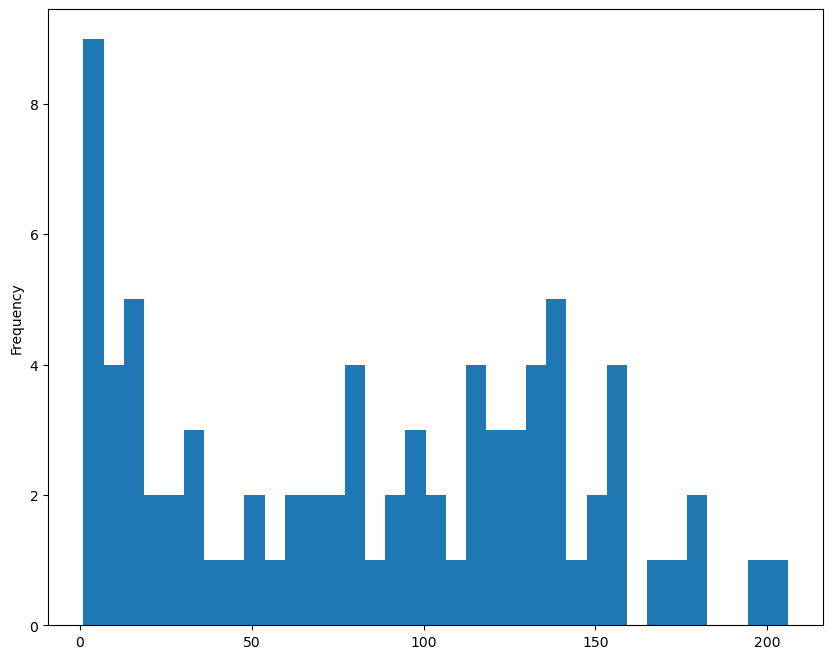

In [13]:
df['Age'].plot.hist(bins = 35, figsize = (10, 8))

<Figure size 1000x800 with 0 Axes>

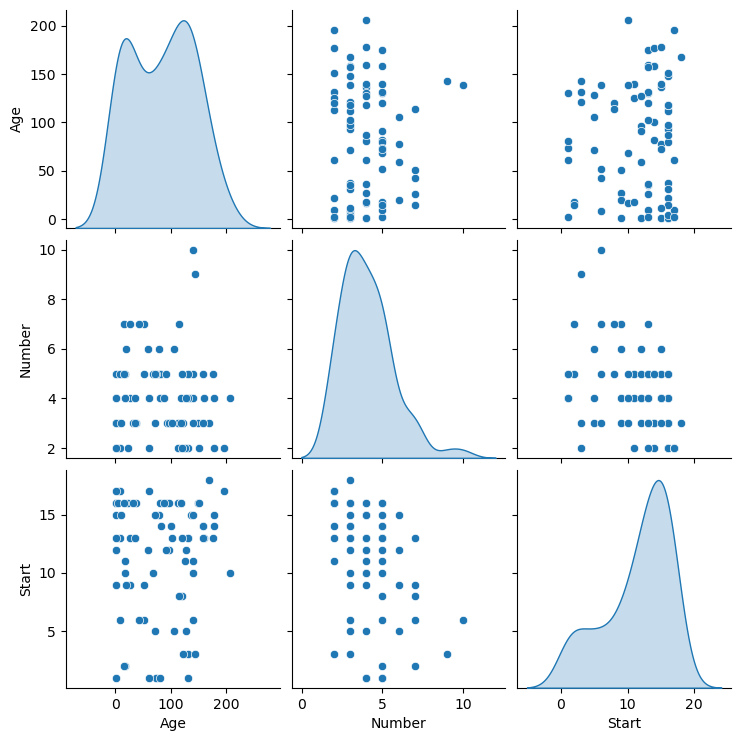

In [14]:
plt.figure(figsize = (10, 8))
sns.pairplot(data, diag_kind = 'kde')
plt.show()

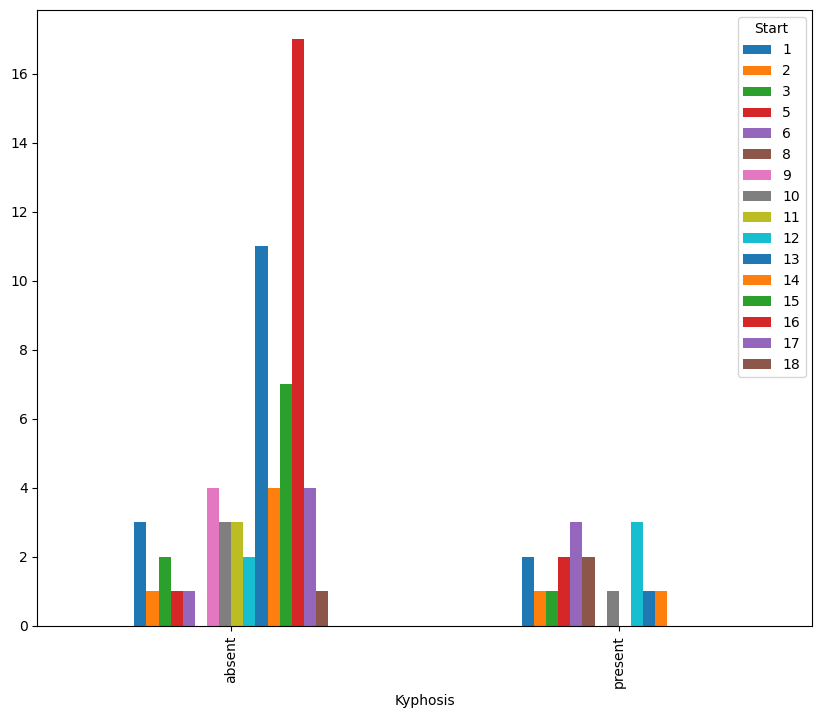

In [15]:
pd.crosstab(df['Kyphosis'], df['Start']).plot(kind = 'bar', figsize = (10, 8))

plt.show()

In [16]:
from scipy.stats import zscore
data2 = data.apply(zscore)
data2

,Age,Number,Start
0,-0.219143,-0.652035,-1.337907
1,1.287494,-0.652035,0.516341
2,0.767964,-0.030684,-1.337907
3,-1.414063,0.590667,-2.162017
4,-1.431381,-0.030684,0.722368
...,...,...,...
76,1.270177,-0.652035,0.310313
77,-0.998439,1.833370,0.310313
78,0.629423,-1.273387,0.310313
79,-0.721356,1.833370,-1.131880


In [17]:
y = df['Kyphosis']
X = df.drop('Kyphosis', axis = 1)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
dmodel = DecisionTreeClassifier()

In [21]:
dmodel.fit(X_train, y_train)

DecisionTreeClassifier()

In [22]:
dmodel.score(X_train, y_train)
#print(f"The Training Accuracy = {dmodel.score}%")

1.0

In [23]:
dpred = dmodel.predict(X_test)
dpred

array(['absent', 'present', 'present', 'absent', 'absent', 'absent',
       'present', 'absent', 'present', 'absent', 'absent', 'present',
       'absent', 'absent', 'absent', 'absent', 'absent'], dtype=object)

In [24]:
test_accuracy = dmodel.score(X_test, y_test)
test_accuracy

1.0

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

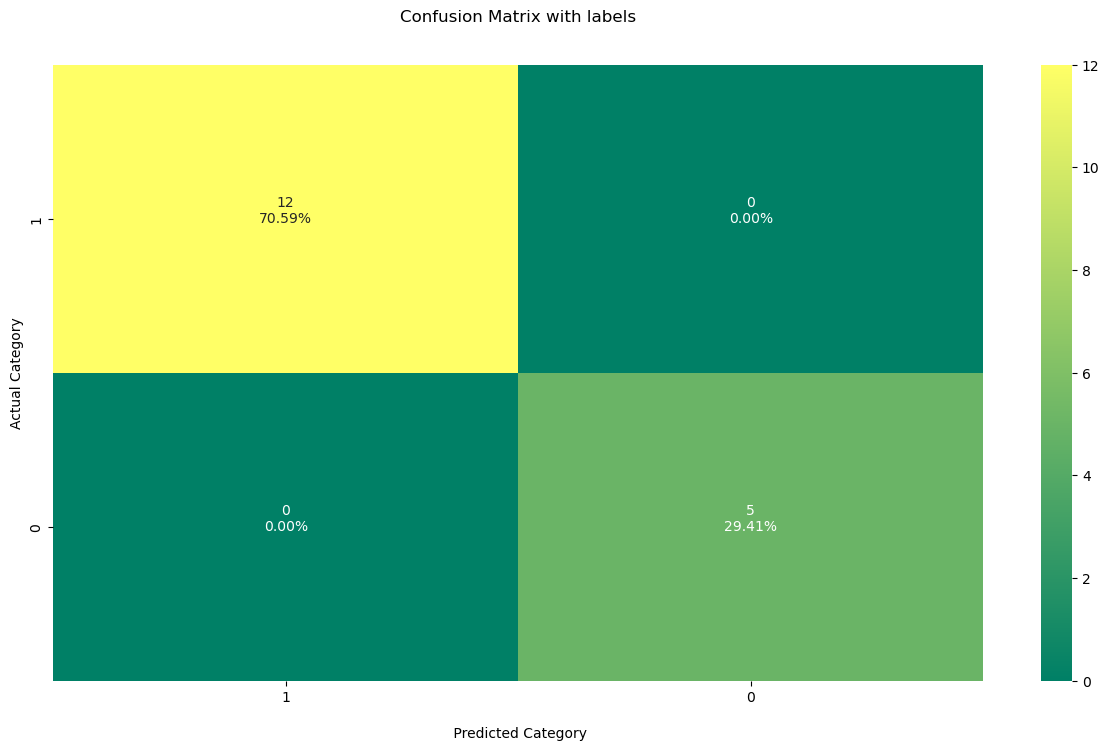

In [26]:
cm = confusion_matrix(y_test, dpred)
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

group_percentage = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n" for v1, v2 in zip(group_counts, group_percentage)]
labels = np.asarray(labels).reshape(2,2)
plt.figure(figsize = (15, 8))
ax = sns.heatmap(cm, annot = labels, fmt = "", cmap = "summer")
                     
ax.set_title("Confusion Matrix with labels\n\n")
                     
ax.set_xlabel("\n Predicted Category")
ax.set_ylabel("Actual Category")
                     
ax.xaxis.set_ticklabels(['1', '0'])
ax.yaxis.set_ticklabels(['1', '0'])
plt.show()

In [27]:
cr = classification_report(y_test, dpred)
print(cr)

              precision    recall  f1-score   support

      absent       1.00      1.00      1.00        12
     present       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



In [28]:
!git ls-files

.gitignore
.ipynb_checkpoints/attempt_kyphosis-checkpoint.ipynb
.ipynb_checkpoints/technical_support_code-checkpoint.ipynb
Cust_Spend_Data.csv
attempt_kyphosis.ipynb
customer_data.ipynb
kyphosis.csv
technical_support_code.ipynb
technical_support_data-2.csv
